In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv("student_data.csv")

In [3]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [9]:
df = pd.get_dummies(df)

In [10]:
df=df.dropna()

In [11]:
X=df.drop("G3",axis=1)
y=df["G3"]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
scaler=StandardScaler()

In [14]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [15]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
mse=cross_val_score(reg,X_train,y_train,cv=10,scoring="neg_mean_squared_error")

In [17]:
np.mean(mse)

np.float64(-3.76172047738579)

In [18]:
predict_reg=reg.predict(X_test)

In [19]:
predict_reg

array([ 6.25083253, 11.83038939,  3.22885433,  9.25756481,  8.7537037 ,
       11.65524566, 18.77414713,  7.15527336,  7.44368684, 12.24559936,
       14.58035661,  5.5699005 , 13.31602777, 11.94371945, 14.64174491,
        8.67680095,  6.09426038, 10.89132007, 13.96446611,  8.09349145,
       13.82710575, 16.35526572, 13.74922118,  5.81789596,  8.04178987,
       20.51960917, 10.74151414,  9.28279971, 16.93978472, 11.08417146,
        9.5589892 ,  6.98634908, 14.63353439, 13.10212711,  5.41313008,
        4.29287071, -2.20240131, 15.43264764, 12.13716351,  7.02916855,
        5.98519352, 10.02659553, 14.51997591,  7.15665628, 17.02899266,
        9.43786772, 11.46660572, 13.59666074, 10.59829511, 15.90188437,
       14.20081173, 14.69621837,  9.92051565,  7.56282074,  3.67557167,
       12.52954999, 10.56965353,  6.73009655, 15.21156289, 16.13212696,
       13.30337338,  7.77373449,  8.73556384,  3.95715071,  3.42072892,
       16.43173533,  8.08520003,  8.82900232,  9.04189945, 16.08

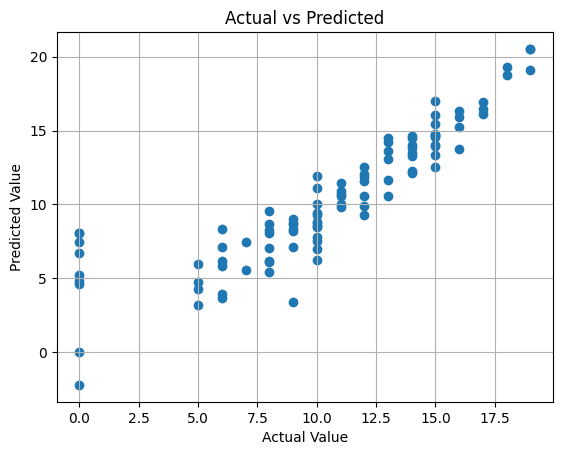

In [24]:
plt.scatter(y_test, predict_reg)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

In [20]:
r2=r2_score(y_test,predict_reg)

In [21]:
r2

0.7811139641406579